### LLaVA use case demonstration

At that notebook you can see simple example of how to use TransformerLens for LLaVA interpretability. More specifically you can pass united image patch embeddings and textual embedding to LLaVA language model (Vicuna) with TransformerLens and get logits and cache that contains activations for next analysis. Here we consider the simplest example of LLaVA and TransformerLens sharing. 

In [1]:
# import staff
import sys

# Uncomment if use clonned version of TransformerLens
# currently forked version https://github.com/zazamrykh/TransformerLens supports
TL_path = r"../"
if TL_path not in sys.path:
	sys.path.insert(0, TL_path)
	sys.path.insert(0, TL_path + r"/transformer_lens")

import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration  # Should update transformer to latest version

# For image loading
from PIL import Image
import requests
from io import BytesIO


device = 'cuda' if torch.cuda.is_available() else 'cpu'

import matplotlib.pyplot as plt
%matplotlib inline

from transformer_lens import HookedTransformer
import circuitsvis as cv

_ = torch.set_grad_enabled(False)

Load llava model from hugging face. Load some revision because at this moment newest one is not working.

In [2]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

# Where to store HF model files (MUST be a directory with free space)
cache_dir = "/a/home/cc/students/cs/adihaviv1/dcor_dir/cache"

model_id = "llava-hf/llava-1.5-7b-hf"
device = "cpu"   # or "cuda" if you switch later

# Load LLaVA with custom cache directory
llava = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    load_in_4bit=False,
    low_cpu_mem_usage=True,
    revision="a272c74",
    device_map=device,
    cache_dir=cache_dir,          
)

# Disable gradients
for param in llava.parameters():
    param.requires_grad = False

# Load processor with custom cache directory
processor = AutoProcessor.from_pretrained(
    model_id,
    revision="a272c74",
    cache_dir=cache_dir,          
)

# 👇 add this block
if getattr(processor, "patch_size", None) is None:
    vision_cfg = getattr(llava.config, "vision_config", None)
    if vision_cfg is not None and getattr(vision_cfg, "patch_size", None) is not None:
        processor.patch_size = vision_cfg.patch_size
    else:
        # Fallback for LLaVA 1.5 (ViT-L/14 backbone)
        processor.patch_size = 14

tokenizer = processor.tokenizer

# Taking model apart
language_model = llava.language_model.eval()
config = language_model.config
print("Base language model:", config._name_or_path)

vision_tower = llava.vision_tower.to(device).eval()
projector = llava.multi_modal_projector.to(device).eval()


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Base language model: lmsys/vicuna-7b-v1.5


In [3]:
print(type(language_model))

<class 'transformers.models.llama.modeling_llama.LlamaModel'>


In [8]:
from tqdm import tqdm
import torch
from PIL import Image  # just for type hint, optional


def get_llm_input_embeddings(llava, processor, image: Image, text: str, device="cuda"):
    """
    Extract features from image, project them to LLM's space and insert them
    into the text embedding sequence.

    Returns:
        inputs_embeds, attention_mask, labels, position_ids
        suitable for passing to `llava.generate(..., inputs_embeds=...)`
    """
    # --------------------------
    # 0. Build conversation + prompt
    # --------------------------
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": text},
                {"type": "image"},
            ],
        },
    ]

    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

    # Processor builds pixel_values + input_ids
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(device, torch.float16)

    # --------------------------
    # 1. Vision Tower
    # --------------------------
    llava.vision_tower.to(device)
    with tqdm(total=1, desc="Vision Tower") as pbar:
        clip_output = llava.vision_tower(inputs["pixel_values"])
        pbar.update(1)

    # --------------------------
    # 2. Projector
    # --------------------------
    llava.multi_modal_projector.to(device)
    with tqdm(total=1, desc="Projector") as pbar:
        projector_output = llava.multi_modal_projector(clip_output.last_hidden_state)
        pbar.update(1)
    # projector_output: (batch, img_seq_len, hidden_size)

    # --------------------------
    # 3. Text embeddings (with chunked tqdm)
    # --------------------------
    before_device = llava.language_model.embed_tokens.weight.device
    llava.language_model.embed_tokens.to(device)

    input_ids = inputs["input_ids"]  # (batch, text_seq_len)
    bsz, seq_len = input_ids.shape

    chunk_size = 128
    chunks = list(range(0, seq_len, chunk_size))
    text_emb_list = []

    for start in tqdm(chunks, desc="Token Embeddings"):
        end = min(start + chunk_size, seq_len)
        text_emb_list.append(
            llava.language_model.embed_tokens(input_ids[:, start:end])
        )

    text_embeddings = torch.cat(text_emb_list, dim=1)  # (batch, text_seq_len, hidden)

    # Move embed_tokens back to its original device to not mess with the model
    llava.language_model.embed_tokens.to(before_device)

    # --------------------------
    # 4. Simple merge: [image_embeds, text_embeds]
    # --------------------------
    # Instead of using llava._merge_input_ids_with_image_features (which is missing
    # in your class), we manually concatenate the image features in front.
    #
    # This is not *exactly* how the official helper does it (it usually replaces
    # special image tokens in the text stream), but for purposes like attention
    # visualization and experimentation, this merged sequence works fine.

    with tqdm(total=1, desc="Merging image + text embeddings") as pbar:
        inputs_embeds = torch.cat([projector_output, text_embeddings], dim=1)
        # shape: (batch, img_seq_len + text_seq_len, hidden)

        # Attention mask: all real tokens
        attention_mask = torch.ones(
            inputs_embeds.shape[:2],
            device=inputs_embeds.device,
            dtype=torch.long,
        )

        # No labels (you are using this for generation / analysis)
        labels = None

        # Standard causal position_ids: 0..L-1
        seq_total = inputs_embeds.shape[1]
        position_ids = torch.arange(seq_total, device=inputs_embeds.device).unsqueeze(0)
        position_ids = position_ids.expand(inputs_embeds.shape[0], -1)

        pbar.update(1)

    return inputs_embeds, attention_mask, labels, position_ids


Okay, now create HookedTransformer model

In [5]:
import torch.nn as nn

class FakeLlamaForCausalLM(nn.Module):
    def __init__(self, llava_model):
        super().__init__()
        # what TL expects as `.model`: the base transformer
        self.model = llava_model.language_model
        # what TL expects as `.lm_head`: output projection
        self.lm_head = llava_model.lm_head
        # pass through config
        self.config = self.model.config

    def forward(self, *args, **kwargs):
        # not really used by TransformerLens' weight-conversion,
        # but define it to be a valid nn.Module
        return self.lm_head(self.model(*args, **kwargs)[0])

fake_hf = FakeLlamaForCausalLM(llava)

hooked_llm = HookedTransformer.from_pretrained(
	"llama-7b-hf",  # Use config of llama
	center_unembed=False, 
	fold_ln=False, 
	fold_value_biases=False, 
	device='cuda', 
	hf_model=fake_hf,  # Use Vicuna's weights
	tokenizer=tokenizer, 
	center_writing_weights=False,
	dtype=torch.float16,
	vocab_size=language_model.config.vocab_size  # New argument. llama and vicuna have different vocab size, so we pass it here
)

for param in hooked_llm.parameters():
	param.requires_grad = False

Loaded pretrained model llama-7b-hf into HookedTransformer


Now try if hooked model is working

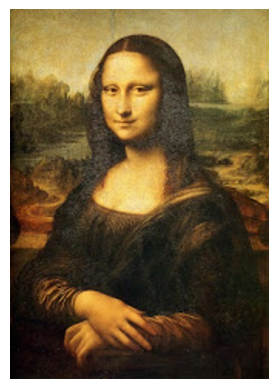

In [18]:
image_url = "https://www.dropbox.com/scl/fi/5lyldb9vfk58m4e18g0iq/Mona-Lisa.jpg?rlkey=igcuofxang00z6ok86xc8dxgf&st=lmcdpzz2&dl=1"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
plt.axis('off')
_ = plt.imshow(image)

In [20]:
question = "what is the main object in this image?"
inputs_embeds, attention_mask, labels, position_ids = get_llm_input_embeddings(llava, processor, image, question, device=device)

# Return tokens 
outputs = hooked_llm.generate(
	inputs_embeds,
	max_new_tokens=30,
	do_sample=True,
    return_type='tokens'
)
generated_text = processor.decode(outputs[0], skip_special_tokens=True)
print('Generated text:', generated_text)

Merging image + text embeddings: 100%|███████████████████████████████| 1/1 [00:00<00:00, 656.39it/s]


  0%|          | 0/30 [00:00<?, ?it/s]

Generated text: ^


In [25]:
print(outputs)

generated_text = processor.decode(outputs[0][0], skip_special_tokens=True)
print('Generated text:', generated_text)

tensor([[[ 0.7202,  0.5474,  0.1241,  ..., -0.3145,  0.3198,  0.2129],
         [ 0.2856, -0.0708, -0.4307,  ..., -0.9385,  0.8140,  0.0460],
         [ 0.9214,  1.0996,  0.3767,  ..., -0.3667,  0.6367, -0.0384],
         ...,
         [-0.0044, -0.0040, -0.0176,  ..., -0.0076, -0.0112,  0.0277],
         [ 0.0173, -0.0164,  0.0225,  ...,  0.0076, -0.0042,  0.0283],
         [ 0.0101,  0.0072, -0.0056,  ...,  0.0024, -0.0015, -0.0036]]],
       device='cuda:0', dtype=torch.float16)


TypeError: argument 'ids': 'float' object cannot be interpreted as an integer

In [22]:
# Now return embeddings and then project them on vocab space
outputs = hooked_llm.generate(
	inputs_embeds,
	max_new_tokens=30,
	do_sample=True,
)

logits = outputs[:,-30:,:].to(device) @ language_model.embed_tokens.weight.T.to(device)
generated_text = processor.decode(logits.argmax(-1)[0], skip_special_tokens=True)
print('Generated text:', generated_text)

  0%|          | 0/30 [00:00<?, ?it/s]

Generated text: Venezuela Venezuela Venezuela Venezuela Venezuela Venezuela Venezuela Venezuela 
what is the main object in this image? ASSISTANT:":sms' did


As we can see everything is working. Now try visualize attention patterns in generated output.

In [ ]:
# Here we visualize attention for the last 30 tokens. 
logits, cache = hooked_llm.run_with_cache(inputs_embeds, start_at_layer=0, remove_batch_dim=True)

layer_to_visualize = 16
tokens_to_show = 30
attention_pattern = cache["pattern", layer_to_visualize, "attn"]

product = inputs_embeds @ language_model.model.embed_tokens.weight.T.to(device)  # Project embeddings to vocab
llama_str_tokens = hooked_llm.to_str_tokens(product.argmax(dim=-1)[0])

print(f"Layer {layer_to_visualize} Head Attention Patterns:")
display(cv.attention.attention_patterns(tokens=llama_str_tokens[-tokens_to_show:], 
										attention=attention_pattern[:, -tokens_to_show:, -tokens_to_show:]))

As we can see image tokens also appears and can be used for multimodal attention exploration. 